<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab/blob/main/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data shape: (857, 22)
Scaled data shape: (857, 22)


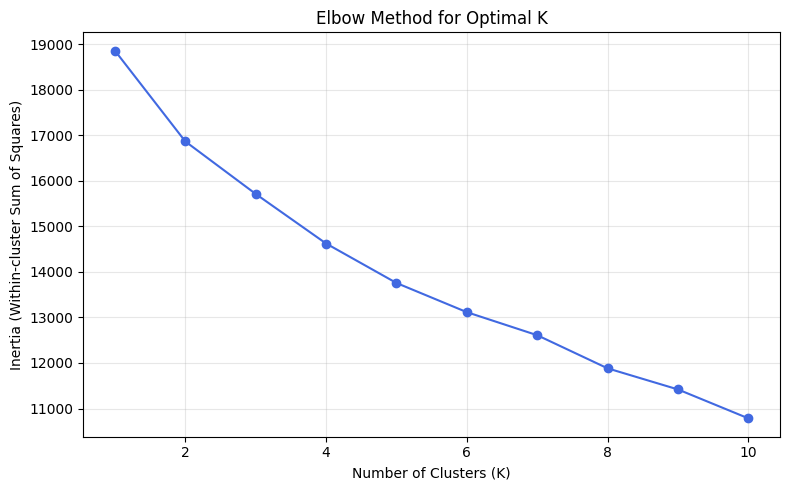

K=2: Silhouette Score = 0.1391
K=3: Silhouette Score = 0.1438
K=4: Silhouette Score = 0.1576
K=5: Silhouette Score = 0.1779
K=6: Silhouette Score = 0.1910
K=7: Silhouette Score = 0.1736
K=8: Silhouette Score = 0.1966
K=9: Silhouette Score = 0.2079
K=10: Silhouette Score = 0.2030


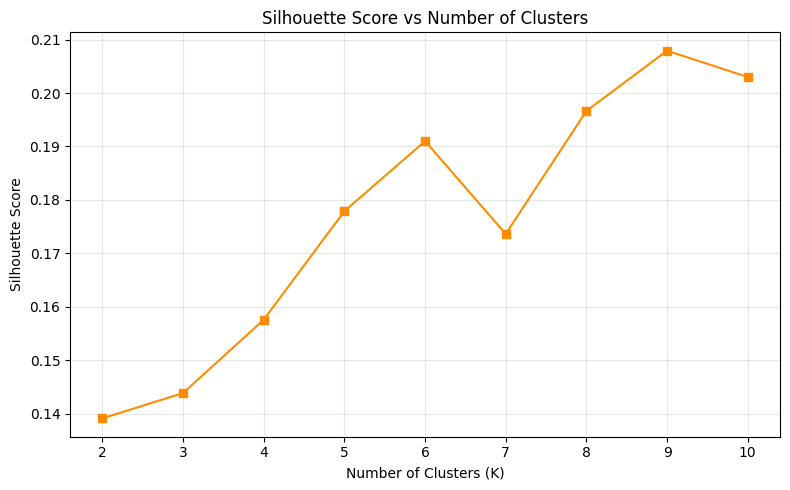


K=2 Inertia: 16862.56
K=2 Silhouette Score: 0.1391

Cluster vs Grade distribution:
Grade    GBM  LGG
Cluster          
0        331   95
1         29  402

PCA Explained Variance: PC1=12.7%, PC2=9.1%


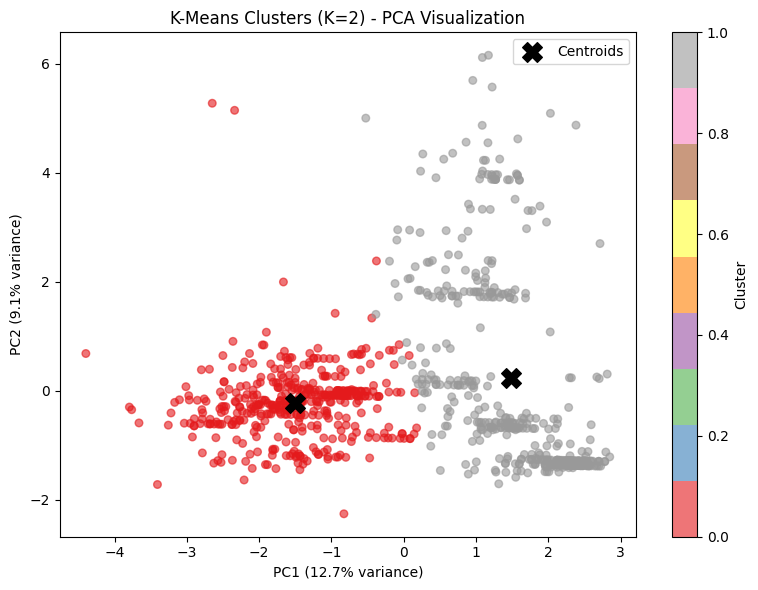

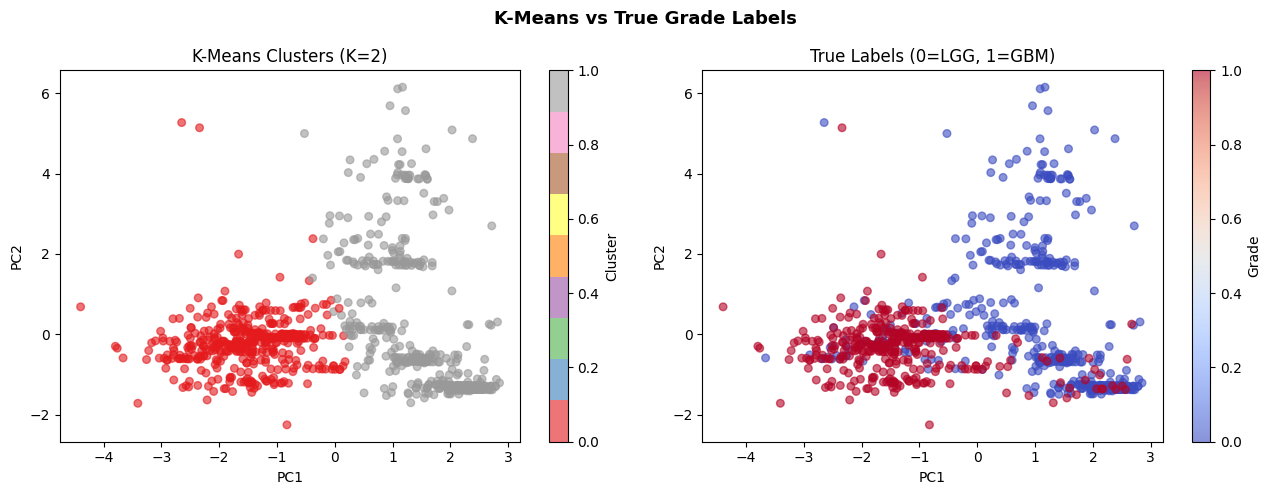


Cluster Profiles (mean):
Cluster          0          1
IDH1      0.011737   0.944316
TP53      0.234742   0.587007
ATRX      0.039906   0.468677
PTEN      0.321596   0.013921
EGFR      0.260563   0.004640
CIC       0.009390   0.255220
MUC16     0.147887   0.083527
PIK3CA    0.103286   0.074246
NF1       0.140845   0.020882
PIK3R1    0.089202   0.044084
FUBP1     0.007042   0.102088
RB1       0.096244   0.000000
NOTCH1    0.007042   0.081206
BCOR      0.032864   0.034803
CSMD3     0.042254   0.023202
SMARCA4   0.014085   0.051044
GRIN2A    0.051643   0.011601
IDH2      0.028169   0.025522
FAT4      0.032864   0.020882
PDGFRA    0.042254   0.009281
Age      60.422535  40.552204


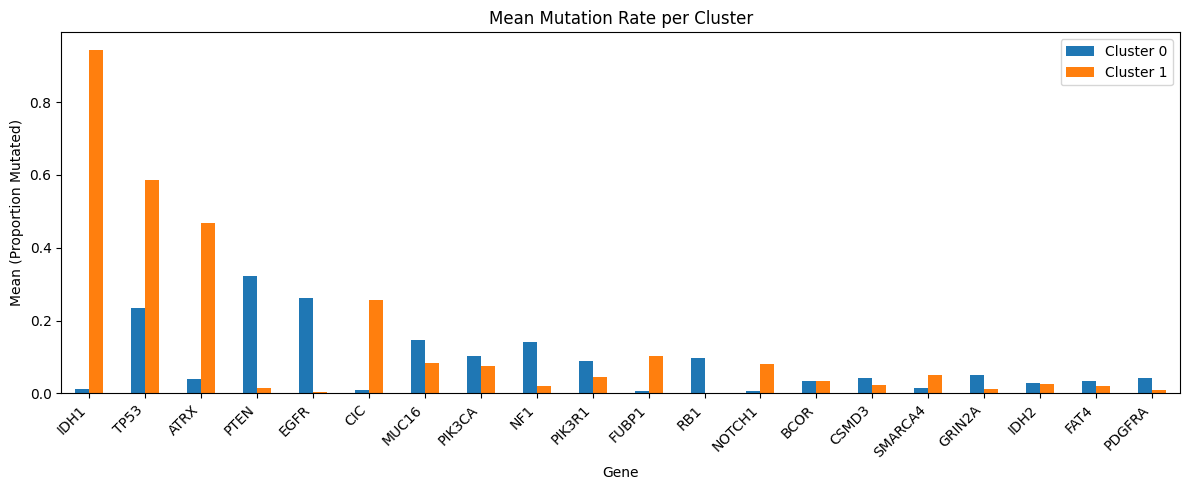

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── Helper & constants ──────────────────────────────────────────
def parse_age(s):
    m = re.search(r'(\d+)\s*years?', str(s))
    return int(m.group(1)) if m else None

mut_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
            'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
            'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']

# ── Load & preprocess ───────────────────────────────────────────
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
df['Age'] = df['Age_at_diagnosis'].apply(parse_age)
for c in mut_cols:
    df[c] = (df[c] == 'MUTATED').astype(int)
df['Gender_num'] = (df['Gender'] == 'Male').astype(int)
df['target'] = (df['Grade'] == 'GBM').astype(int)
df = df.dropna(subset=['Age'])

feature_cols = mut_cols + ['Age', 'Gender_num']
X = df[feature_cols].values
print("Data shape:", X.shape)

# ── Feature Scaling ─────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)

# ── Elbow Method ────────────────────────────────────────────────
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='royalblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Silhouette Scores ───────────────────────────────────────────
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"K={k}: Silhouette Score = {sil_scores[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='s', color='darkorange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── K-Means with K=2 ────────────────────────────────────────────
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = km2.fit_predict(X_scaled)
df['Cluster'] = labels2

print(f"\nK=2 Inertia: {km2.inertia_:.2f}")
print(f"K=2 Silhouette Score: {silhouette_score(X_scaled, labels2):.4f}")
print("\nCluster vs Grade distribution:")
print(pd.crosstab(df['Cluster'], df['Grade']))

# ── PCA Visualization ───────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA Explained Variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels2, cmap='Set1', alpha=0.6, s=30)
centers_pca = pca.transform(km2.cluster_centers_)
ax.scatter(centers_pca[:,0], centers_pca[:,1], c='black', marker='X', s=200, label='Centroids')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (K=2) - PCA Visualization')
ax.legend()
plt.tight_layout()
plt.show()

# ── Clusters vs True Grade ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels2, cmap='Set1', alpha=0.6, s=30)
axes[0].set_title('K-Means Clusters (K=2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')
sc2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=df['target'].values, cmap='coolwarm', alpha=0.6, s=30)
axes[1].set_title('True Labels (0=LGG, 1=GBM)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Grade')
plt.suptitle('K-Means vs True Grade Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Cluster Profiles ────────────────────────────────────────────
cluster_profile = df.groupby('Cluster')[mut_cols + ['Age']].mean()
print("\nCluster Profiles (mean):")
print(cluster_profile.T.to_string())

cluster_profile[mut_cols].T.plot(kind='bar', figsize=(12, 5))
plt.title('Mean Mutation Rate per Cluster')
plt.ylabel('Mean (Proportion Mutated)')
plt.xlabel('Gene')
plt.legend(['Cluster 0', 'Cluster 1'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()